# Importing Libraries

In [1]:
from umap import UMAP # for UMAP latent space projections
import sys # for relatove imports of sigma

Using relative imports for sigma and its packages whilst they are being redeveloped

In [2]:
sys.path.insert(0,"..")

from sigma.utils import normalisation as norm 
from sigma.utils import visualisation as visual
from sigma.utils.load import SEMDataset
from sigma.src.utils import same_seeds
from sigma.src.dim_reduction import Experiment
from sigma.models.autoencoder import AutoEncoder
from sigma.src.segmentation import PixelSegmenter
from sigma.gui import gui
from sigma.utils.loadtem import TEMDataset

# Loading the data

In [3]:
file_path='TFL_run1 23000418 Area 1 Site 1 Map Data 5.h5oina'

In [4]:
import h5py
import numpy as np
import hyperspy.api as hs

# === File paths ===
input_file = file_path
output_file = "window_integrals.hdf5"

y_dim=1024

# === Open file ===
with h5py.File(input_file, 'r') as f:
    win_int_path = "1/EDS/Data/Window Integral"
    element_names = list(f[win_int_path].keys())
    
    # Load maps
    maps = [f[f"{win_int_path}/{el}"][:] for el in element_names]
    data = np.stack(maps, axis=0)  # Shape: (elements, Y, X)
    
    # Transpose to match HyperSpy: (Y, X, elements)
    data = np.moveaxis(data, 0, -1)

    # Axis scaling from metadata
    x_scale = f["1/EDS/Header/X Step"][()]
    y_scale = f["1/EDS/Header/Y Step"][()]

    # Metadata
    metadata = {}
    for key in f["1/EDS/Header"].keys():
        try:
            val = f[f"1/EDS/Header/{key}"][()]
            if isinstance(val, bytes):
                val = val.decode('utf-8')
            metadata[key] = val
        except:
            pass



# === Create HyperSpy signal ===
s_tmp = hs.signals.Signal2D(data,dtype='float32') # creating a temporary file that contains all of the data but is the wrong shape
s=hs.signals.Signal1D(s_tmp.data.reshape(int(len(s_tmp.as_signal1D(spectral_axis=0).data)/y_dim),y_dim,len(maps)),dtype='float32')


# Set axes
s.axes_manager.navigation_axes[0].name = "Y"
s.axes_manager.navigation_axes[0].scale = y_scale
s.axes_manager.navigation_axes[1].name = "X"
s.axes_manager.navigation_axes[1].scale = x_scale

s.axes_manager.signal_axes[0].name = "Element Index"
s.axes_manager.signal_axes[0].units = ""
s.axes_manager.signal_axes[0].size = len(element_names)

# Add element labels
s.metadata.set_item("Element list", element_names)

# Add header metadata
s.metadata.General.title = "EDS Window Integral Maps"
#s.metadata.Sample.name = metadata.get("Specimen Label", "Unknown")
#s.metadata.Sample.description = metadata.get("Specimen Notes", "")
s.original_metadata = metadata

#saving
s.save(output_file,overwrite=True)



AttributeError: 'bytes' object has no attribute 'dtype'

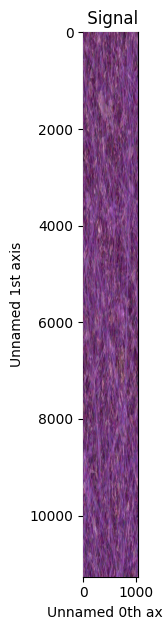

In [39]:
s.change_dtype('rgb8')
s.plot()

In [4]:
sem.set_xray_lines(['C_Ka', 'O_Ka', 'Mg_Ka', 'Al_Ka', 
                    'Si_Ka', 'Ti_Ka','S_Ka', 'Ca_Ka',  
                    'Fe_Ka', 'Ni_Ka'])
# dont want to bin, but we will do normalise
tem.remove_fist_peak(0.1)
tem.peak_intensity_normalisation()

Set xray_lines to ['C_Ka', 'O_Ka', 'Mg_Ka', 'Al_Ka', 'Si_Ka', 'Ti_Ka', 'S_Ka', 'Ca_Ka', 'Fe_Ka', 'Ni_Ka']
Removing the fisrt peak by setting the intensity to zero until the energy of 0.1 keV.
Normalising the chemical intensity along axis=2, so that the sum is equal to 1 along axis=2.


<EDSTEMSpectrum, title: , dimensions: (64, 64|2000)>

In [5]:
gui.view_dataset(tem)

Output()

Output()

# Processing steps before umap projection

In [6]:
tem.normalisation([norm.neighbour_averaging,norm.zscore,norm.softmax])

Set feature_list to ['C_Ka', 'O_Ka', 'Mg_Ka', 'Al_Ka', 'Si_Ka', 'Ti_Ka', 'S_Ka', 'Ca_Ka', 'Fe_Ka', 'Ni_Ka']
Normalise dataset using:
    1. neighbour_averaging
    2. zscore
    3. softmax


In [7]:
gui.view_pixel_distributions(tem,norm_list=[norm.neighbour_averaging,norm.zscore,norm.softmax],cmap='Reds')

# Latent Space Projection with UMAP

In [8]:
data = tem.normalised_elemental_data.reshape(-1,len(tem.feature_list))
umap = UMAP(
        n_neighbors=20,
        min_dist=0.05,
        n_components=2,
        metric='euclidean'
    )
latent = umap.fit_transform(data)

# Pixel Segmentation

## Segmentation with GMM

In [9]:
ps_gmm=PixelSegmenter(latent=latent,dataset=tem,method='GaussianMixture',method_args={'n_components' :50, 'random_state':6, 'init_params':'kmeans'} )

Initial viewing of the latent space

In [10]:
gui.view_latent_space(ps=ps_gmm, color=True)

Interacting with clusters in the latent space, by clicking to merge their colours.

The merged clusters can be saved, by creating a new ps creater function (which is output by `interactive_latent_plot`), then calling this function to create a new PixelSegmenter object.

In [11]:
get_new_ps = gui.interactive_latent_plot(ps_gmm,ratio_to_be_shown=1.0)


Create the new PixelSegmenter object with the merged clusters and visualise with the existing tools by calling the newliy created function.

In [14]:
new_ps=get_new_ps()

In [15]:
gui.check_latent_space(ps=new_ps,show_map=True,ratio_to_be_shown=1.0)

alt.HConcatChart(...)